## Modelo T com data augmentation

In [1]:
from keras.utils import image_dataset_from_directory

train_dir = './train'
validation_dir = './validation'
test_dir = './test'

IMG_SIZE = 150

train_dataset = image_dataset_from_directory(train_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

validation_dataset = image_dataset_from_directory(validation_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

test_dataset = image_dataset_from_directory(test_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

Found 40000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


A única diferença, relativamente ao modelo sem data augmentation, é que colocamos conv_base.trainable = False, isto vai congelar as camadas, ou seja, os pesos da rede pré-treinada não vão ser alterados. Isto é feito para aproveitar os features já aprendidos pela rede.

In [2]:
from tensorflow.keras.applications.vgg16 import VGG16

conv_base = VGG16(weights='imagenet', include_top=False)
conv_base.trainable = False
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, None, None, 128)   0     

In [3]:
for data_batch, labels_batch in train_dataset:
  print('data batch shape:', data_batch.shape)
  print('labels batch shape:', labels_batch.shape)
  break

data batch shape: (32, 150, 150, 3)
labels batch shape: (32,)


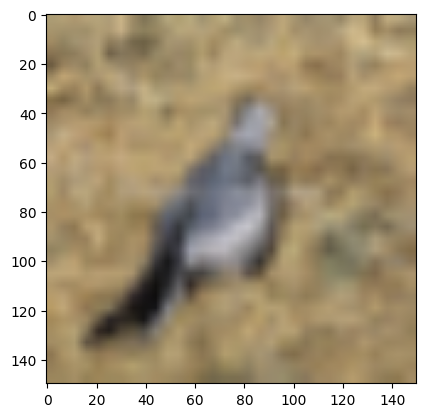

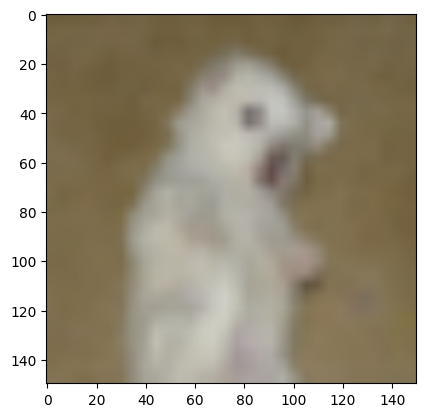

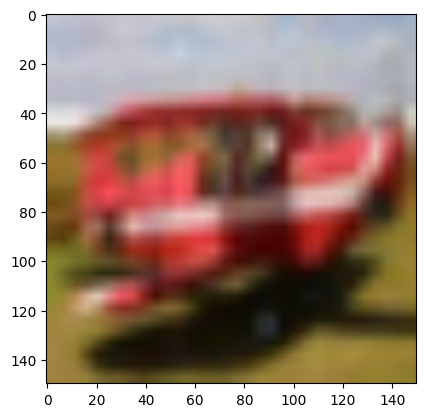

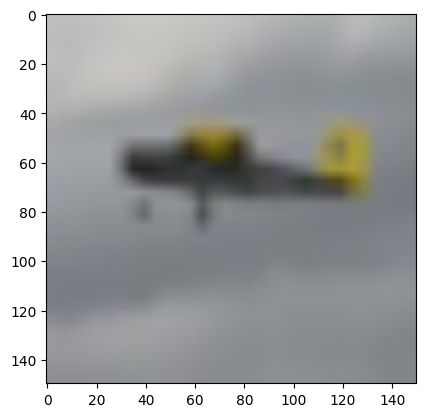

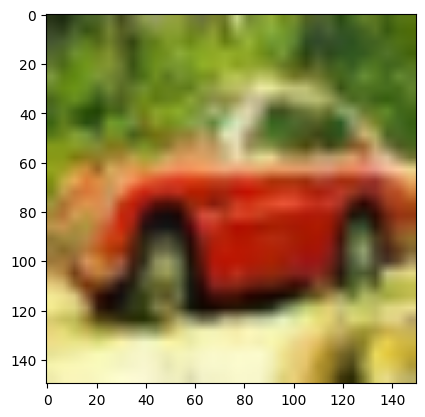

In [4]:
import matplotlib.pyplot as plt
for data_batch, _ in train_dataset.take(1):
  for i in range(5):
      plt.imshow(data_batch[i].numpy().astype("uint8"))
      plt.show()

Aqui adicionamos à rede o data augmentation, que é uma técnica que consiste em aplicar transformações aleatórias às imagens. As transformações aleatórias que aplicamos foram:
    
    - RandomFlip: consiste em inverter a imagem e no nosso caso invertemos horizontalmente
    
    - RandomRotation: consiste em rodar a imagem num ângulo aleatório e no nosso caso rodamos a imagem dentro de um intervalo de -0.1 a 0.1 radianos
    
    - RandomZoom: consiste em fazer zoom aleatório na imagem e no nosso caso fizemos zoom até 20%

Isto é feito para aumentar a quantidade de dados de treino e evitar o overfitting que foi observado no modelo anterior.

Esta linha de código 'x = data_augmentation(inputs)' foi acrescentada para aplicar as transformações aleatórias às imagens.

Esta linha de código 'x = keras.applications.vgg16.preprocess_input(x)' foi acrescentada, pois esta realiza o pré-processamento das imagens para que estas possam ser usadas na rede VGG16.

In [6]:
from tensorflow import keras
from keras import layers

data_augmentation = keras.Sequential(
 [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
 ]
)

inputs = keras.Input(shape=(150, 150, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs, outputs)

In [7]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

Neste callback guardamos o melhor modelo no ficheiro modelo_T_with_data_augmentation.h5.

In [8]:
callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss",patience=10), keras.callbacks.ModelCheckpoint(filepath='modelo_T_with_data_augmentation.h5', save_best_only=True, monitor='val_loss')]

In [13]:
history = model.fit(train_dataset, epochs=100, validation_data=validation_dataset, callbacks=callbacks)

Epoch 1/100
1250/1250 [==============================] - 558s 446ms/step - loss: 11.0107 - accuracy: 0.7272 - val_loss: 3.3248 - val_accuracy: 0.8200
Epoch 2/100
1250/1250 [==============================] - 565s 452ms/step - loss: 3.9779 - accuracy: 0.7369 - val_loss: 2.3296 - val_accuracy: 0.8022
Epoch 3/100
1250/1250 [==============================] - 570s 456ms/step - loss: 3.1682 - accuracy: 0.7433 - val_loss: 2.2988 - val_accuracy: 0.8202
Epoch 4/100
1250/1250 [==============================] - 570s 456ms/step - loss: 3.1092 - accuracy: 0.7542 - val_loss: 2.1618 - val_accuracy: 0.8275
Epoch 5/100
1250/1250 [==============================] - 571s 456ms/step - loss: 3.2949 - accuracy: 0.7603 - val_loss: 2.3003 - val_accuracy: 0.8270
Epoch 6/100
1250/1250 [==============================] - 576s 460ms/step - loss: 3.3484 - accuracy: 0.7702 - val_loss: 2.2059 - val_accuracy: 0.8366
Epoch 7/100
1250/1250 [==============================] - 569s 455ms/step - loss: 3.5121 - accuracy: 0.773

Depois de treinar o modelo, fizemos o gráfico da loss e da accuracy do conjunto de treino e validação.

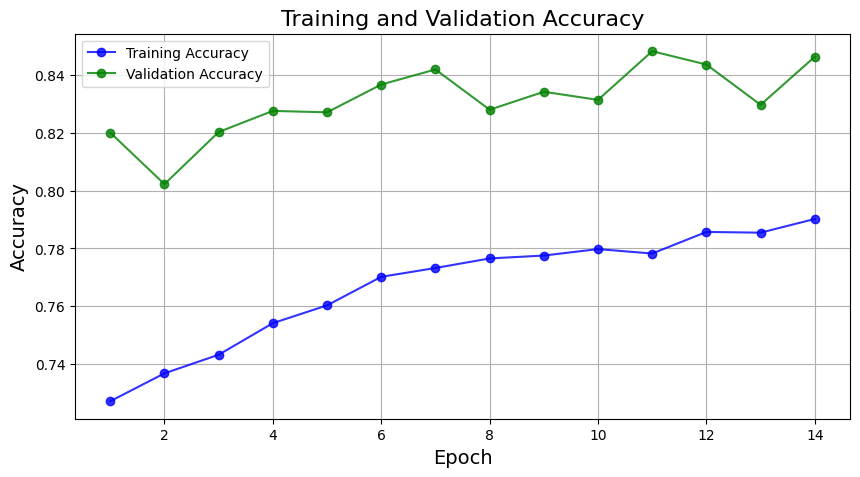

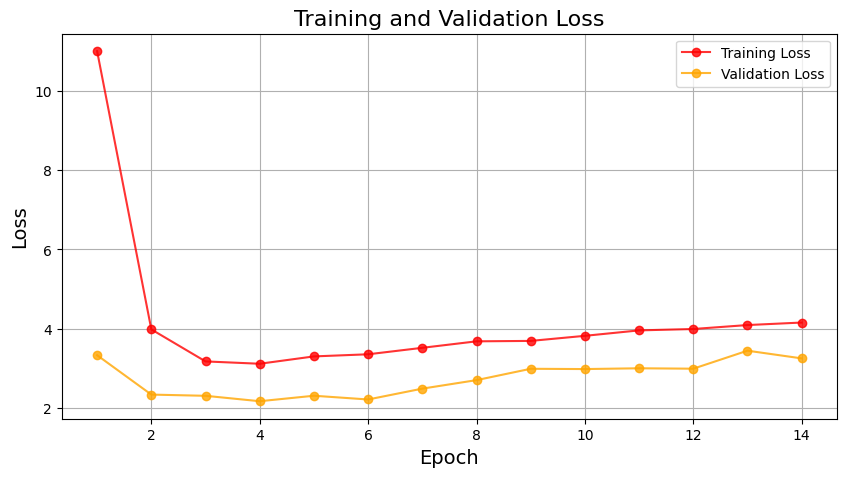

In [14]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, acc, 'o-', label='Training Accuracy', color='blue', alpha=0.8)
plt.plot(epochs, val_acc, 'o-', label='Validation Accuracy', color='green', alpha=0.8)
plt.title('Training and Validation Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, 'o-', label='Training Loss', color='red', alpha=0.8)
plt.plot(epochs, val_loss, 'o-', label='Validation Loss', color='orange', alpha=0.8)
plt.title('Training and Validation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()
plt.grid(True)

plt.show()

Ao observar os dados e o gráfico, conseguimos observar que o modelo com data augmentation tem menos accuracy tanto no conjunto de treino quanto no conjunto de validação comparativamente com o modelo sem data augmentation, mas a loss no conjunto de validação é menor neste modelo. **No entanto, o modelo com data augmentation já não apresenta overfitting**.

No entanto, este modelo apresenta **underfitting**, ou seja, a accuracy do conjunto de treino é sempre inferior à accuracy do conjunto de validação e a loss do conjunto de treino é sempre superior à loss do conjunto de validação.

A accuracy do conjunto de treino está progessivamente ao aumentar chegando a um valor máximo de 0.7902 na época 14, a accuracy do conjunto de validação também aumenta chegando a um valor de 0.8462 na última época. 

A loss no conjunto de treino começa com um valor muito alto, 11.01, mas vai diminuindo até à época 14, onde atinge o valor de 4.15, a loss do conjunto de validação começa num valor mais baixo, 3.32, e fica mais ou menos estagnado nos intervalos de 2 e 3 de loss.

Aqui fazemos o load ao melhor modelo para fazer o evaluate com o conjunto de teste.

Pelos resultados obtidos, observamos que a accuracy do conjunto de teste é de 0.82, ou seja, acerta em 82% das imagens, e a loss é de 2.25.

Para minimizar o underfitting, nós aplicamos o **fine-tuning** ao modelo, que consiste em descongelar algumas camadas da rede VGG16.

In [9]:
model_T_augmentation = keras.models.load_model('modelo_T_with_data_augmentation.h5')
test_loss, test_acc = model_T_augmentation.evaluate(test_dataset)
print('test_acc:', test_acc)
print('test_loss:', test_loss)

313/313 [==============================] - 63s 169ms/step - loss: 2.2473 - accuracy: 0.8236
test_acc: 0.8235999941825867
test_loss: 2.247262716293335


1/1 [==============================] - 0s 208ms/step


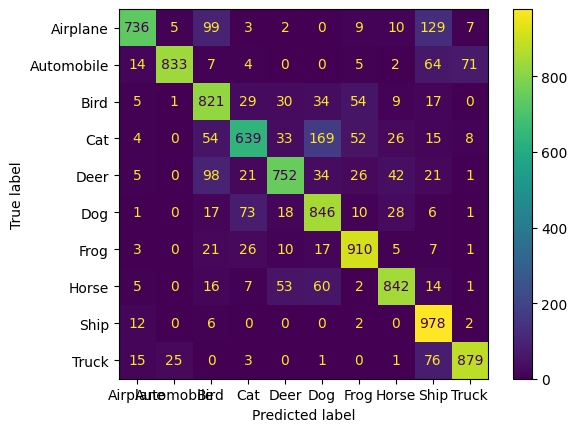

In [13]:
import numpy as np
from sklearn import metrics


y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model_T_augmentation.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

conf_mat = metrics.confusion_matrix(y_true, y_pred)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"])
cm_display.plot()
plt.show()

Por análise da matriz de confusão, entende-se que o modelo apresenta resultados maioritariamente satisfatórios, com exceção de algumas classes que apresentam uma taxa de acerto menor. A destacar são as classes 'airplane' e 'cat', que são aquelas em que o modelo apresenta maior dificuldade em classificar corretamente, tendo em 1000 imagens acertado em 736 e 639, respetivamente. Outro ponto a destacar é que a classe 'cat' é algumas vezes confundida (169 vezes) com a classe 'dog'. As classes com maior taxa de acerto são 'frog' e 'ship', com 910 e 978 imagens corretamente classificadas, respetivamente.

Neste código, nós apenas fizemos o predict de uma imagem para ver se ele consegue prever a classe correta da imagem.

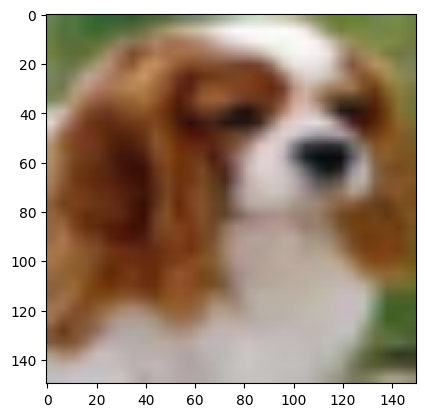

(1, 150, 150, 3)
1/1 [==============================] - 1s 1s/step
Result:  dog
Result:  [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


In [14]:
from keras.preprocessing import image
import numpy as np
import tensorflow as tf

img = tf.keras.preprocessing.image.load_img('./test/005_dog/blenheim_spaniel_s_000123.png', target_size=(150, 150), interpolation='bilinear')
plt.imshow(img)
plt.show()
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
print(img_array.shape)
result = model_T_augmentation.predict(img_array)
whatIsIt = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

predicted_classes = result.round()
predicted_indices = np.where(predicted_classes == 1)[1]

for index in predicted_indices:
    print("Result: ", whatIsIt[index])
print("Result: ", result.round())

Pelo o output obtido, podemos ver que o modelo consegue prever a classe correta da imagem.

## Modelo T Com Fine Tuning

In [15]:
from keras.utils import image_dataset_from_directory

train_dir = './train'
validation_dir = './validation'
test_dir = './test'

IMG_SIZE = 150 

train_dataset = image_dataset_from_directory(train_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

validation_dataset = image_dataset_from_directory(validation_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

test_dataset = image_dataset_from_directory(test_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

Found 40000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


Aqui alteramos o modelo anterior para aplicar o fine-tuning. Para isso, descongelamos as últimas 4 camadas da rede VGG16.

In [16]:
from tensorflow.keras.applications.vgg16 import VGG16

conv_base = VGG16(weights='imagenet', include_top=False)
conv_base.trainable = True

for layer in conv_base.layers[:-4]:
    layer.trainable = False
    
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, None, None, 128)   0     

In [17]:
for data_batch, labels_batch in train_dataset:
  print('data batch shape:', data_batch.shape)
  print('labels batch shape:', labels_batch.shape)
  break

data batch shape: (32, 150, 150, 3)
labels batch shape: (32,)


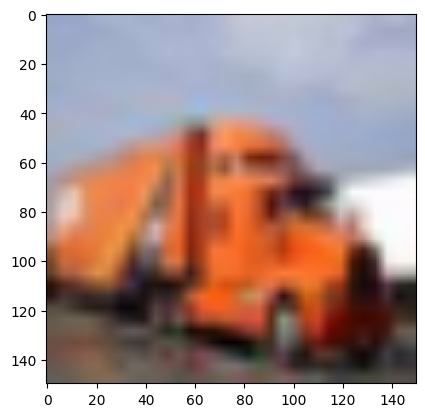

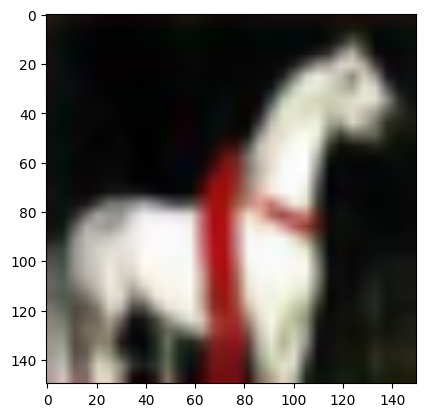

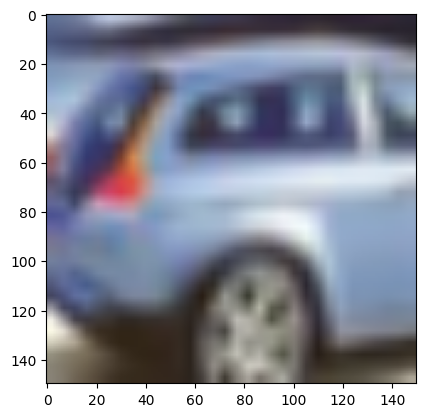

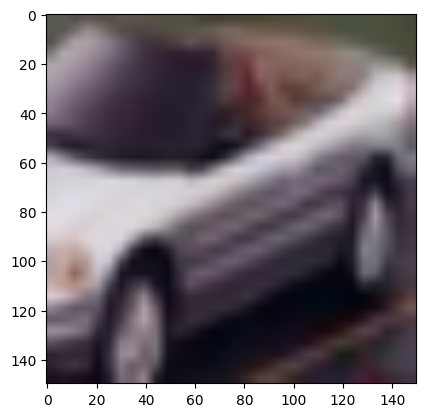

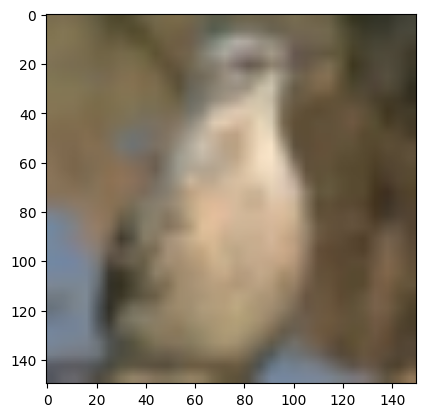

In [18]:
import matplotlib.pyplot as plt
for data_batch, _ in train_dataset.take(1):
  for i in range(5):
      plt.imshow(data_batch[i].numpy().astype("uint8"))
      plt.show()

In [19]:
from tensorflow import keras
from keras import layers

data_augmentation = keras.Sequential(
 [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
 ]
)

inputs = keras.Input(shape=(150, 150, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs, outputs)

Alteramos o compile, colocando o learning_rate=1e-5. Colocar learning_rate = 1e-5 significa que estamos a reduzir a taxa de aprendizagem. Isto é feito para que o modelo não faça alterações muito grandes nos pesos das camadas descongeladas.

In [20]:
model.compile(loss="sparse_categorical_crossentropy",optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),metrics=["accuracy"])

Neste callback guardamos o melhor modelo no ficheiro modelo_T_with_data_augmentation_and_fine_tuning.h5.

In [21]:
callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss",patience=10), keras.callbacks.ModelCheckpoint(filepath='modelo_T_with_data_augmentation_and_fine_tuning.h5', save_best_only=True, monitor='val_loss')]

In [26]:
history = model.fit(train_dataset, epochs=100, validation_data=validation_dataset, callbacks=callbacks)

Epoch 1/100
1250/1250 [==============================] - 663s 531ms/step - loss: 2.1617 - accuracy: 0.3692 - val_loss: 0.9347 - val_accuracy: 0.6844
Epoch 2/100
1250/1250 [==============================] - 719s 573ms/step - loss: 1.0064 - accuracy: 0.6658 - val_loss: 0.6597 - val_accuracy: 0.7859
Epoch 3/100
1250/1250 [==============================] - 726s 580ms/step - loss: 0.7616 - accuracy: 0.7534 - val_loss: 0.5490 - val_accuracy: 0.8283
Epoch 4/100
1250/1250 [==============================] - 684s 547ms/step - loss: 0.6413 - accuracy: 0.7935 - val_loss: 0.5118 - val_accuracy: 0.8421
Epoch 5/100
1250/1250 [==============================] - 690s 552ms/step - loss: 0.5550 - accuracy: 0.8186 - val_loss: 0.4651 - val_accuracy: 0.8592
Epoch 6/100
1250/1250 [==============================] - 702s 562ms/step - loss: 0.5026 - accuracy: 0.8408 - val_loss: 0.4498 - val_accuracy: 0.8689
Epoch 7/100
1250/1250 [==============================] - 744s 595ms/step - loss: 0.4436 - accuracy: 0.8568

Depois de treinar o modelo, fizemos o gráfico da loss e da accuracy do conjunto de treino e validação.

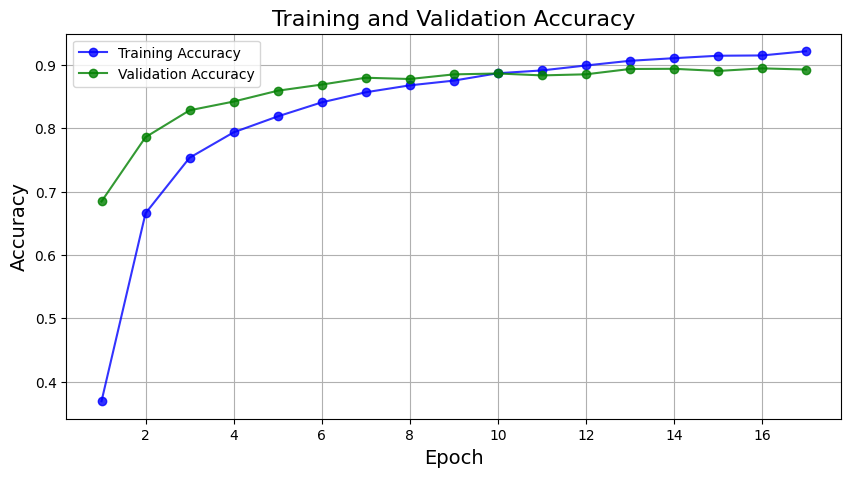

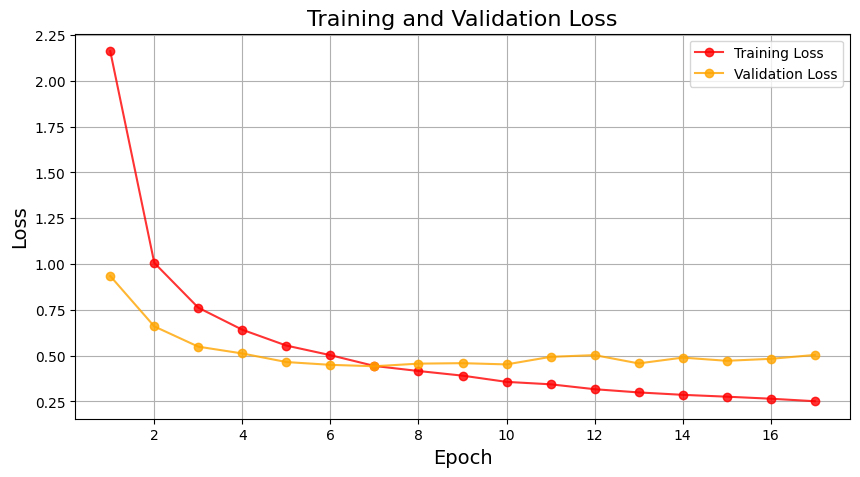

In [27]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, acc, 'o-', label='Training Accuracy', color='blue', alpha=0.8)
plt.plot(epochs, val_acc, 'o-', label='Validation Accuracy', color='green', alpha=0.8)
plt.title('Training and Validation Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, 'o-', label='Training Loss', color='red', alpha=0.8)
plt.plot(epochs, val_loss, 'o-', label='Validation Loss', color='orange', alpha=0.8)
plt.title('Training and Validation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()
plt.grid(True)

plt.show()

Ao observar o gráfico, conseguimos observar que já não exite nem overfitting nem underfitting, ou seja, os valores de accuracy e loss do conjunto de treino e validação são muito próximos.

Os valores da accuracy do conjunto de treino, inicialmente eram mais baixos que os valores da accuracy do conjunto de validação, mas a partir da época 11, a accuracy do conjunto de treino é maior que a accuracy do conjunto de validação. A accuracy do conjunto de treino está progessivamente ao aumentar chegando a um valor máximo de 0.9215 na época 17, a accuracy do conjunto de validação também aumenta chegando a um valor de 0.8926 na última época.

A loss no conjunto de treino começa com um valor mais alto que o conjunto de validação, mas ambos vão diminuindo até ao final das épocas, só que a partir da época 8 a loss do conjunto de treino é menor que a loss do conjunto de validação. Inicialmente, o conjunto de treino começa com um valor de loss 2.16, mas na última época a loss vai para 0.25. A loss do conjunto de validação começa com um valor de 0.93 e na última época a loss é de 0.50

Aqui fazemos o load ao melhor modelo para fazer o evaluate com o conjunto de teste.

Pelos resultados obtidos, observamos que a accuracy do conjunto de teste é de 0.87, ou seja, acerta em 87% das imagens, e a loss é de 0.45.

Observamos aqui que o modelo T com fine-tuning apresenta melhores resultados que o modelo anterior.

No final do evaluate guardamos este modelo, no ficheiro 'best_model_T.5', como sendo o melhor modelo.

**OBERVAÇÃO**: nós enganamo-nos e corremos este código novamente e por isso os valores no output são iguais ao modelo seguinte, mas o output correto é o que eu disse: 0.87 arredondado de accuracy e 0.45 arredondado de loss.

In [22]:
model_T_fine_tuning = keras.models.load_model('modelo_T_with_data_augmentation_and_fine_tuning.h5')
test_loss, test_acc = model_T_fine_tuning.evaluate(test_dataset)
print('test_acc:', test_acc)
print('test_loss:', test_loss)

best_model = model_T_fine_tuning.save('best_model_T.h5')

313/313 [==============================] - 50s 157ms/step - loss: 0.4614 - accuracy: 0.8761
test_acc: 0.8761000037193298
test_loss: 0.46142110228538513


1/1 [==============================] - 0s 195ms/step


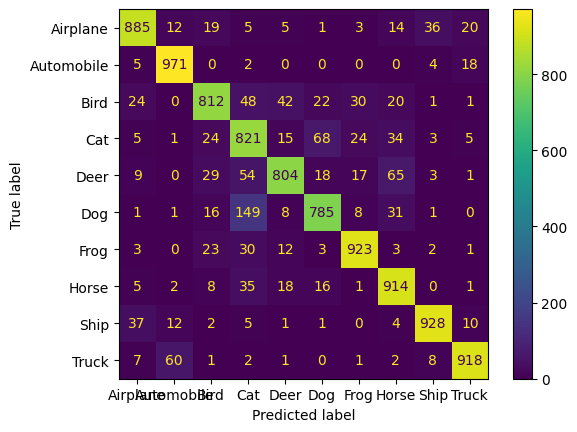

In [23]:
import numpy as np
from sklearn import metrics


y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model_T_fine_tuning.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

conf_mat = metrics.confusion_matrix(y_true, y_pred)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"])
cm_display.plot()
plt.show()

Por análise da matriz de confusão, entende-se que o modelo apresenta resultados muito bons em todas as classes. A destacar são as classes 'deer' e 'dog', que são aquelas em que o modelo apresenta maior dificuldade em classificar corretamente, apesar de terem valores de acerto bastante altos também, tendo em 1000 imagens acertado em 804 e 785, respetivamente. Outro ponto a destacar é que a classe 'dog' é algumas vezes confundida (149 vezes) com a classe 'cat'. As classes com maior taxa de acerto são 'automobile' e 'ship', com 971 e 928 imagens corretamente classificadas, respetivamente.

Neste código, nós apenas fizemos o predict de uma imagem para ver se ele consegue prever a classe correta da imagem.

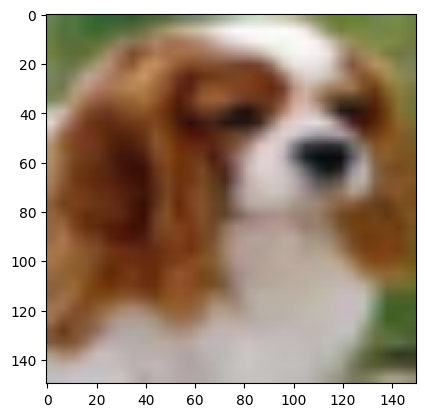

(1, 150, 150, 3)
1/1 [==============================] - 0s 31ms/step
Result:  dog
Result:  [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


In [24]:
from keras.preprocessing import image
import numpy as np
import tensorflow as tf

img = tf.keras.preprocessing.image.load_img('./test/005_dog/blenheim_spaniel_s_000123.png', target_size=(150, 150), interpolation='bilinear')
plt.imshow(img)
plt.show()
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
print(img_array.shape)
result = model_T_fine_tuning.predict(img_array)
whatIsIt = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

predicted_classes = result.round()
predicted_indices = np.where(predicted_classes == 1)[1]

for index in predicted_indices:
    print("Result: ", whatIsIt[index])
print("Result: ", result.round())

Pelo o output obtido, podemos ver que o modelo consegue prever a classe correta da imagem.

## Modelo T Com Fine Tuning mas alteração no data augmentation

In [2]:
from keras.utils import image_dataset_from_directory

train_dir = './train'
validation_dir = './validation'
test_dir = './test'

IMG_SIZE = 150 

train_dataset = image_dataset_from_directory(train_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

validation_dataset = image_dataset_from_directory(validation_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

test_dataset = image_dataset_from_directory(test_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

Found 40000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


In [3]:
from tensorflow.keras.applications.vgg16 import VGG16

conv_base = VGG16(weights='imagenet', include_top=False)
conv_base.trainable = True

for layer in conv_base.layers[:-4]:
    layer.trainable = False
    
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, None, None, 128)   0     

In [4]:
for data_batch, labels_batch in train_dataset:
  print('data batch shape:', data_batch.shape)
  print('labels batch shape:', labels_batch.shape)
  break

data batch shape: (32, 150, 150, 3)
labels batch shape: (32,)


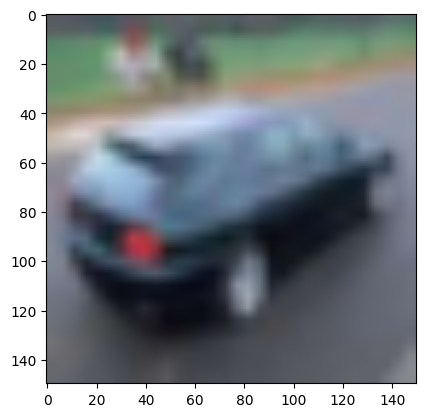

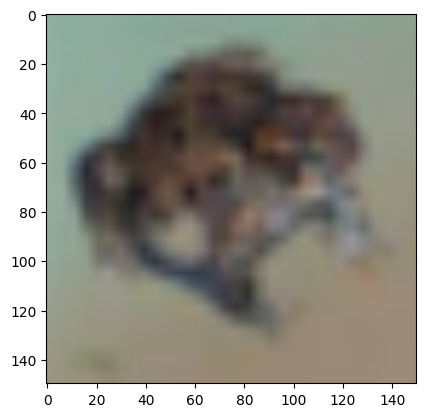

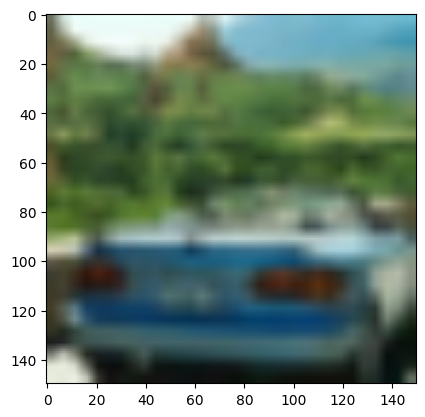

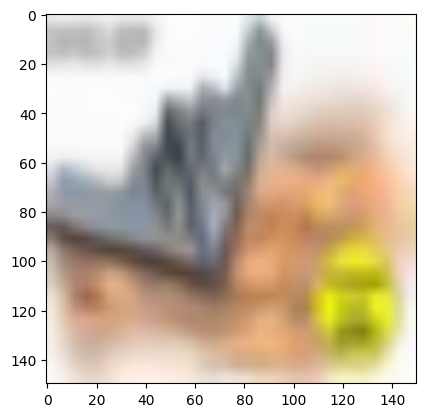

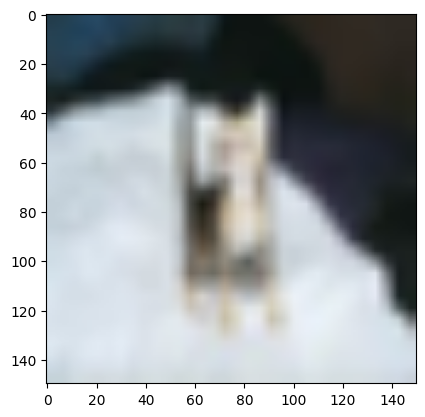

In [5]:
import matplotlib.pyplot as plt
for data_batch, _ in train_dataset.take(1):
  for i in range(5):
      plt.imshow(data_batch[i].numpy().astype("uint8"))
      plt.show()

Aqui alteramos o data augmentation, relativamente ao modelo anterior.

Adicionamos mais transformações aleatórias às imagens, que são:

    - RandomContrast: consiste em alterar a intensidade do contraste na imagem e nosso caso alteramos o contraste da imagem dentro de um intervalo de -10% a 10%
    
    - RandomTranslation: consiste em fazer translação aleatória na imagem e no nosso caso fizemos translação horizontal e vertical, ou seja, as imagens podem ser deslocadas até 10% da altura e largura

    - RandomBrightness: consiste em alterar a intensidade do brilho na imagem e no nosso caso alteramos o brilho da imagem dentro de um intervalo de -10% a 10%

In [8]:
from tensorflow import keras
from keras import layers

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.1),
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        layers.RandomBrightness(0.1),
    ]
)

inputs = keras.Input(shape=(150, 150, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs, outputs)

In [9]:
model.compile(loss="sparse_categorical_crossentropy",optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),metrics=["accuracy"])

In [10]:
callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss",patience=10), keras.callbacks.ModelCheckpoint(filepath='modelo_T_with_data_augmentation_and_fine_tuning.h5', verbose=1, save_best_only=True, monitor='val_loss')]

In [12]:
history = model.fit(train_dataset, epochs=100, validation_data=validation_dataset, callbacks=callbacks)

Epoch 1/100
1250/1250 [==============================] - ETA: 0s - loss: 2.1963 - accuracy: 0.3387
Epoch 1: val_loss improved from inf to 1.06707, saving model to modelo_T_with_data_augmentation_and_fine_tuning.h5
1250/1250 [==============================] - 1428s 1s/step - loss: 2.1963 - accuracy: 0.3387 - val_loss: 1.0671 - val_accuracy: 0.6380
Epoch 2/100
1250/1250 [==============================] - ETA: 0s - loss: 1.1129 - accuracy: 0.6184
Epoch 2: val_loss improved from 1.06707 to 0.72720, saving model to modelo_T_with_data_augmentation_and_fine_tuning.h5
1250/1250 [==============================] - 1357s 1s/step - loss: 1.1129 - accuracy: 0.6184 - val_loss: 0.7272 - val_accuracy: 0.7612
Epoch 3/100
1250/1250 [==============================] - ETA: 0s - loss: 0.8512 - accuracy: 0.7182
Epoch 3: val_loss improved from 0.72720 to 0.61679, saving model to modelo_T_with_data_augmentation_and_fine_tuning.h5
1250/1250 [==============================] - 1294s 1s/step - loss: 0.8512 - accu

Depois de treinar o modelo, fizemos o gráfico da loss e da accuracy do conjunto de treino e validação.

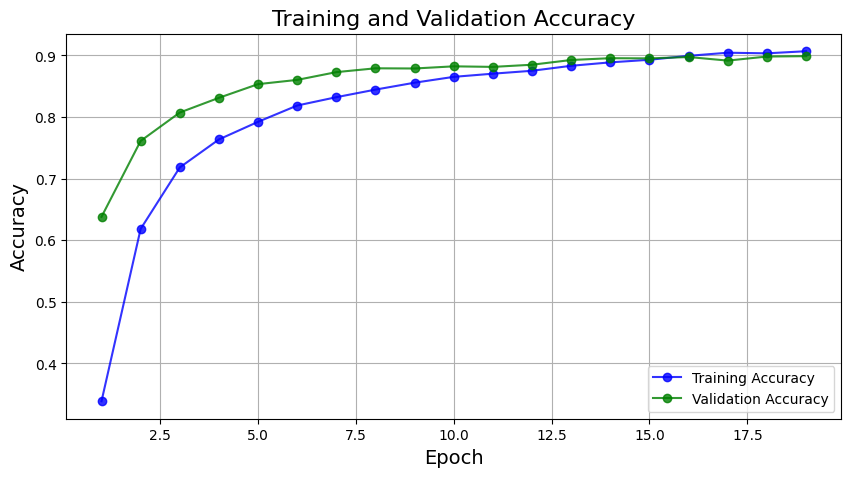

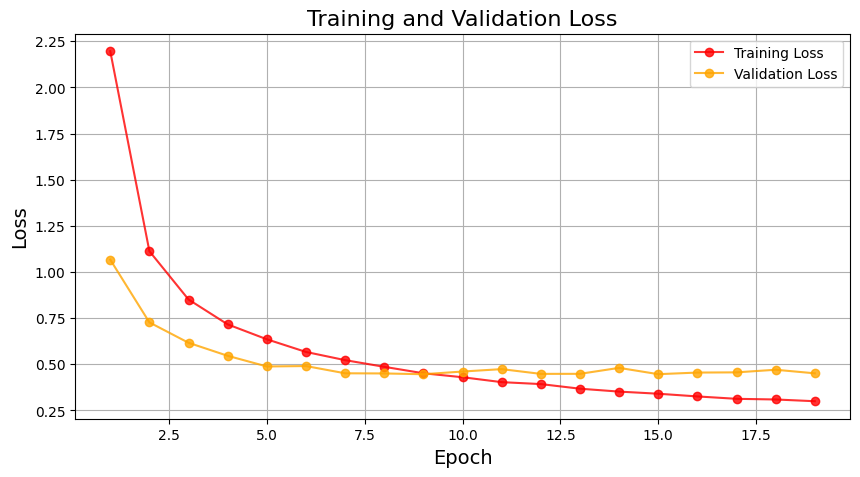

In [13]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, acc, 'o-', label='Training Accuracy', color='blue', alpha=0.8)
plt.plot(epochs, val_acc, 'o-', label='Validation Accuracy', color='green', alpha=0.8)
plt.title('Training and Validation Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, 'o-', label='Training Loss', color='red', alpha=0.8)
plt.plot(epochs, val_loss, 'o-', label='Validation Loss', color='orange', alpha=0.8)
plt.title('Training and Validation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()
plt.grid(True)

plt.show()

Ao observar o gráfico, conseguimos observar que é bastante semelhante ao modelo anterior, ou seja, já não exite nem overfitting nem underfitting, ou seja, os valores de accuracy e loss do conjunto de treino e validação são muito próximos.

Os valores da accuracy do conjunto de treino, inicialmente eram mais baixos que os valores da accuracy do conjunto de validação, mas a partir da época 17, a accuracy do conjunto de treino é maior que a accuracy do conjunto de validação. A accuracy do conjunto de treino está progessivamente ao aumentar chegando a um valor máximo de 0.9068 na época 19, a accuracy do conjunto de validação também aumenta chegando a um valor de 0.8988 na última época.

A loss no conjunto de treino começa com um valor mais alto que o conjunto de validação, mas ambos vão diminuindo até ao final das épocas, só que a partir da época 10 a loss do conjunto de treino é menor que a loss do conjunto de validação. Inicialmente, o conjunto de treino começa com um valor de loss 2.20, mas na última época a loss vai para 0.30. A loss do conjunto de validação começa com um valor de 1.07 e na última época a loss é de 0.45.

Aqui fazemos o load ao melhor modelo para fazer o evaluate com o conjunto de teste.

Pelos resultados obtidos, observamos que a accuracy do conjunto de teste é de 0.88, ou seja, acerta em 88% das imagens, e a loss é de 0.46.

Observamos aqui que o modelo T com fine-tuning e o modelo T com fine-tuning mas com alteração no data augmentation apresenta melhores resultados que os modelos anteriores.

Não guardamos este modelo como sendo o melhor, porque tanto este como o outro modelo têm os resultados bastante semelhantes. Neste modelo também não fizemos o predict de uma imagem, porque o output seria igual ao do modelo anterior e também não fizemos a matriz de confusão, porque o comportamento da matriz de confusão neste modelo ia ser bastante sememlhante à do modelo anterior, ia apresentar resultados muito bons em todas as classes.

In [14]:
model_T_fine_tuning = keras.models.load_model('modelo_T_with_data_augmentation_and_fine_tuning.h5')
test_loss, test_acc = model_T_fine_tuning.evaluate(test_dataset)
print('test_acc:', test_acc)
print('test_loss:', test_loss)

313/313 [==============================] - 53s 165ms/step - loss: 0.4614 - accuracy: 0.8761
test_acc: 0.8761000037193298
test_loss: 0.46142086386680603


## Conclusão

Ao fazer o modelo T, concluimos que os melhores modelos são aqueles em que é aplicado o fine-tuning, pois apresentam melhores resultados que os modelos restantes.

Também podemos concluir que o data augmentation é uma técnica que ajuda a evitar o overfitting, pois ao aplicar o data augmentation, o modelo já não apresenta overfitting. No entanto, ao aplicarmos o data augmentation, o modelo apresenta underfitting. 

Outra conclusão que podemos tirar é que o fine-tuning ajuda a evitar o underfitting, pois ao aplicar o fine-tuning ao modelo com data augmentation, o modelo já não apresenta underfitting.

## Notas finais

Eu e o meu colega tivemos problemas em usar a GPU para treinar os modelos, acabamos por conseguir usar a GPU, mas foi mais para a véspera da entrega do projeto. Nós inicialmente estavamos a utilizar a CPU, mas reparamos que ia demorar demasiado tempo, principalmente no modelo T com data augmentation, sendo preciso mais de 48 horas só para treinar o modelo. Foi por isso que não conseguimos fazer uma das experiências que provavelmente era preciso fazer que é alterar o número de camadas descongeladas no fine-tuning. A nossa ideia principal foi descongelar as últimas 4 camadas e depois ir descongelando mais camadas para ver se conseguimos melhorar o modelo. Infelizmente, não tivemos tempo para fazer isso, devido ao contra tempo que tivemos com a GPU.